# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 41     |  |
| :-------------|:-------------|
| Floor van de Schaft | 6246648 |
| Bruno Schouten | 6577423 |
| Job Kruisdijk | 6278108 |

In [ ]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Floor', 'Bruno','Job']

## Opdracht 1: Planning.

| Planning Groep: 41     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren  | 11:15- 12:00 |
| Testen meetopstelling | 12:00 - 12:30 |
| Eerste iteratie| 13:30 - 14:30 |
| Tweede iteratie en eindalgoritme | 14:30 - 16:00 |
| Testen eindalgoritme | 16:00 - 16:30 |
| Opruimen en inleveren | 16:30 - 17:30 |
| groep aanwezig 1| 10:45 - 12:30 |
| groep aanwezig 2| 13:30 - 16:30 |
| Pauze 1| 10:30 - 10:45 |
| Pauze 2| 12:30 - 13:30 |

## Opdracht 2: Import libs.

In [4]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep 41
<img src="kalibreer.png" width="400">

a =  0.03432830410620591 b =  0.8885045331885933


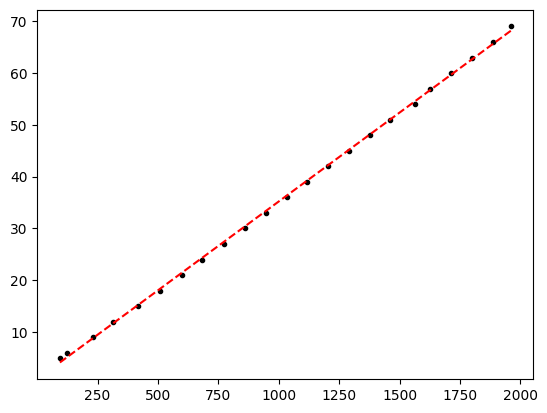

In [14]:
afstanden = np.array([5,6,9,12,15,18,21,24,27,30,33,36,39,42,45,48,51,54,57,60,63,66,69])
bits = np.array([94,124,230,314,417,510,600,683,773,858,945,1033,1118,1205,1290,1377,1460,1565,1627,1712,1800,1888,1960])

def fit(x,a,b):
    return a*x+b
popt,pcov = curve_fit(fit,bits,afstanden)
x_fit = np.linspace(min(bits),max(bits),1000)
y_fit = fit(x_fit, *popt)
plt.plot(bits,afstanden,'k.')
plt.plot(x_fit,y_fit,'r--')

print('a = ', popt[0], 'b = ', popt[1])


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  78.0
1   0  30   0  20  46.7
2  40   0  30   0  42.3
3  30   0  20   0  42.2


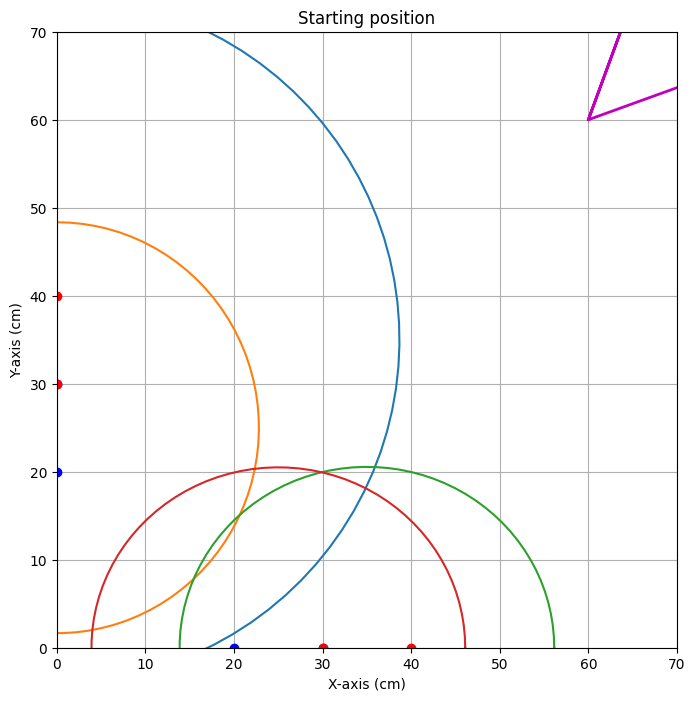


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=89.655


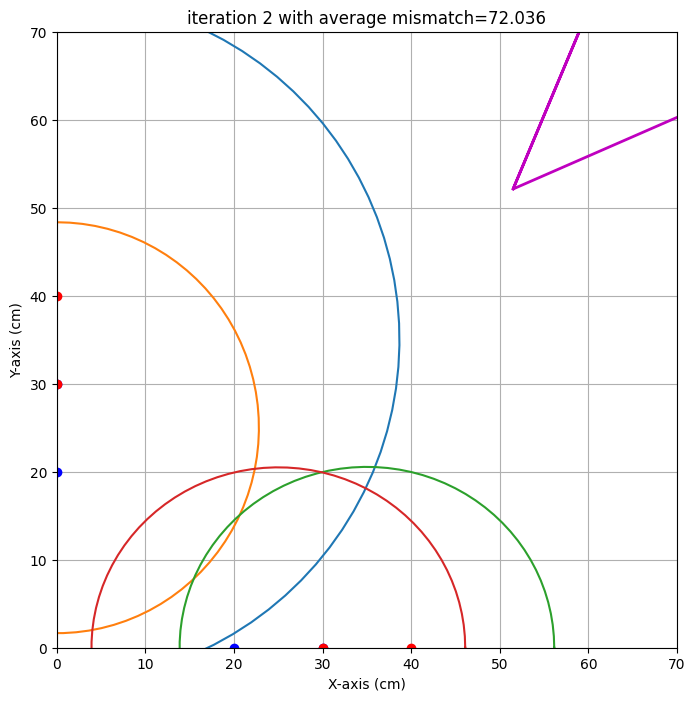

end iteration 2 with average mismatch=72.036


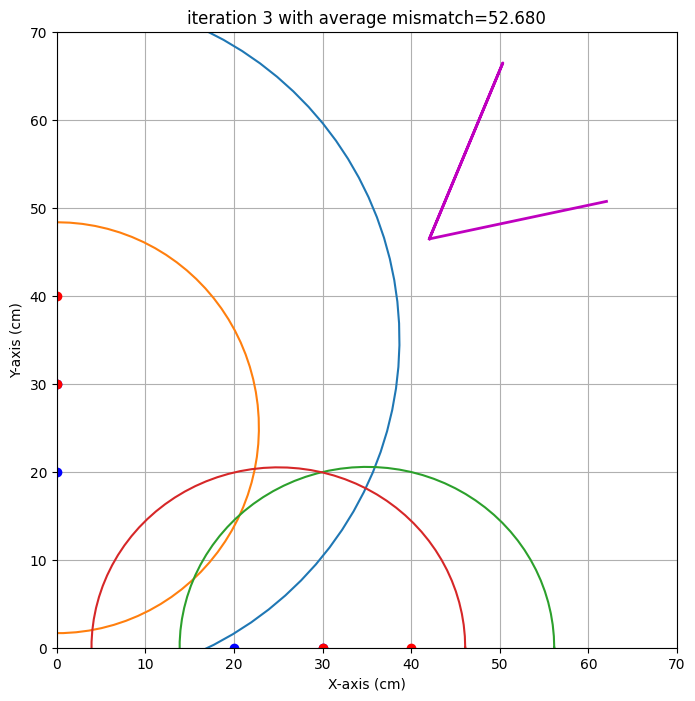

end iteration 3 with average mismatch=52.680


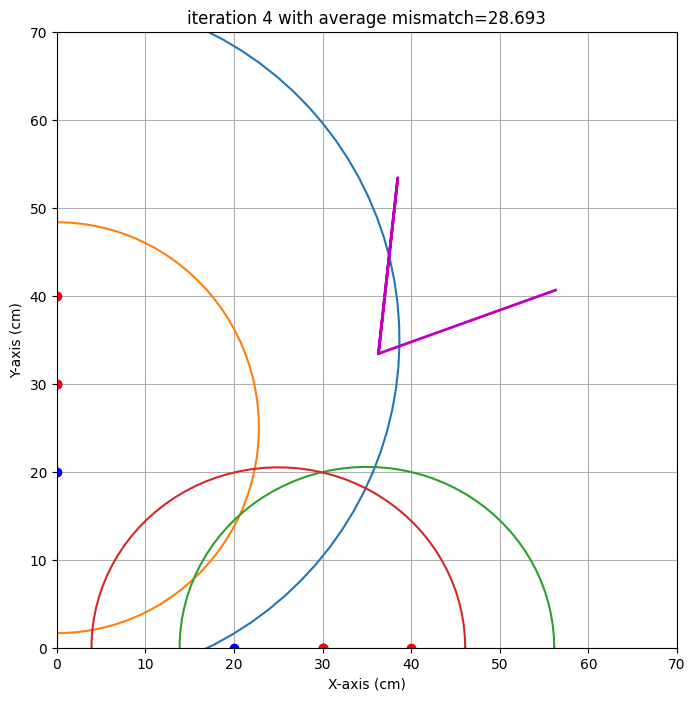

end iteration 4 with average mismatch=28.693


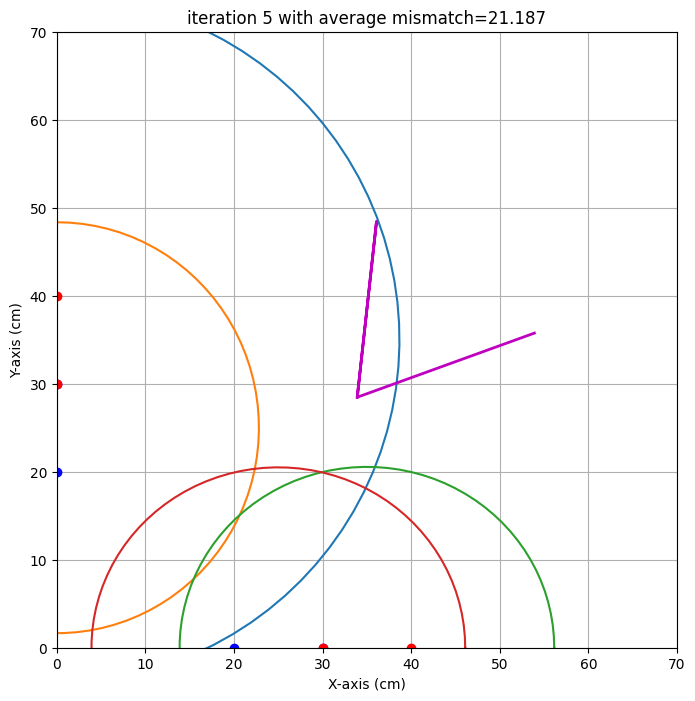

end iteration 5 with average mismatch=21.187


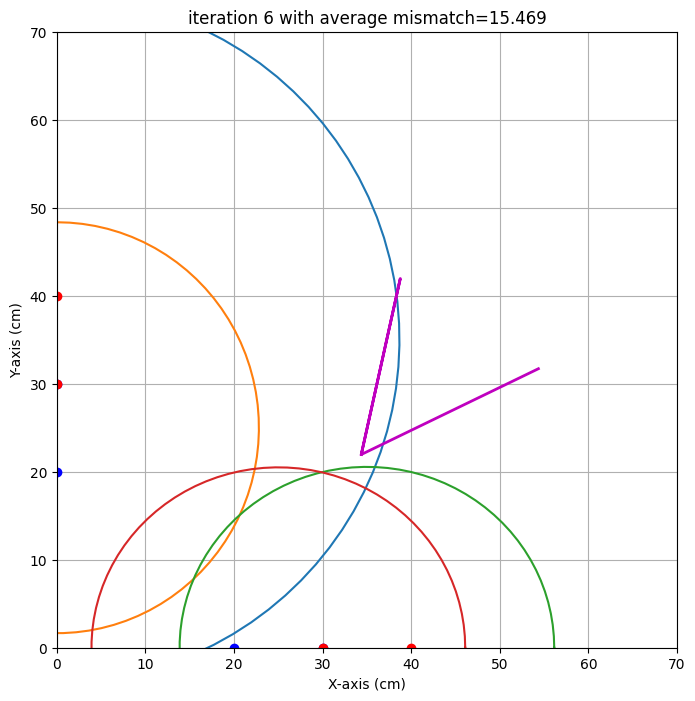

end iteration 6 with average mismatch=15.469


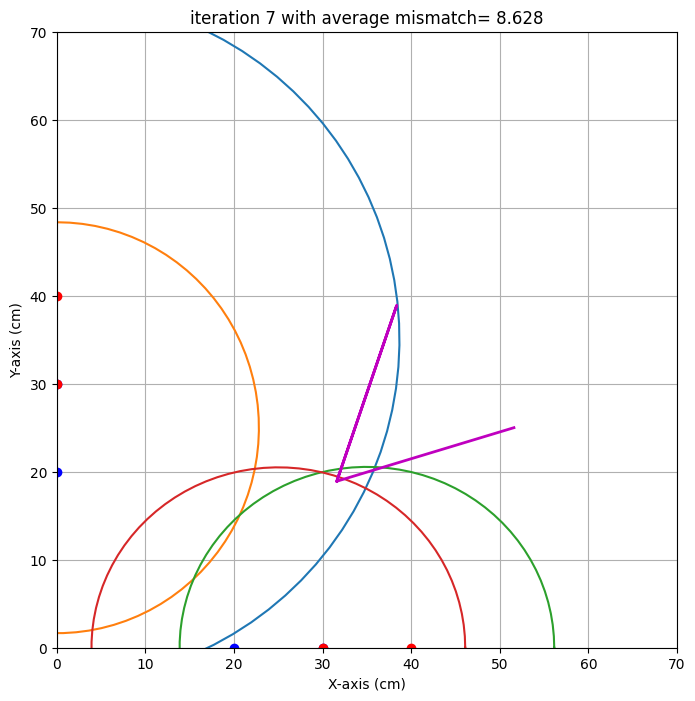

end iteration 7 with average mismatch= 8.628
end iteration 8 with average mismatch= 8.468
end iteration 9 with average mismatch= 7.815
end iteration 10 with average mismatch= 7.191


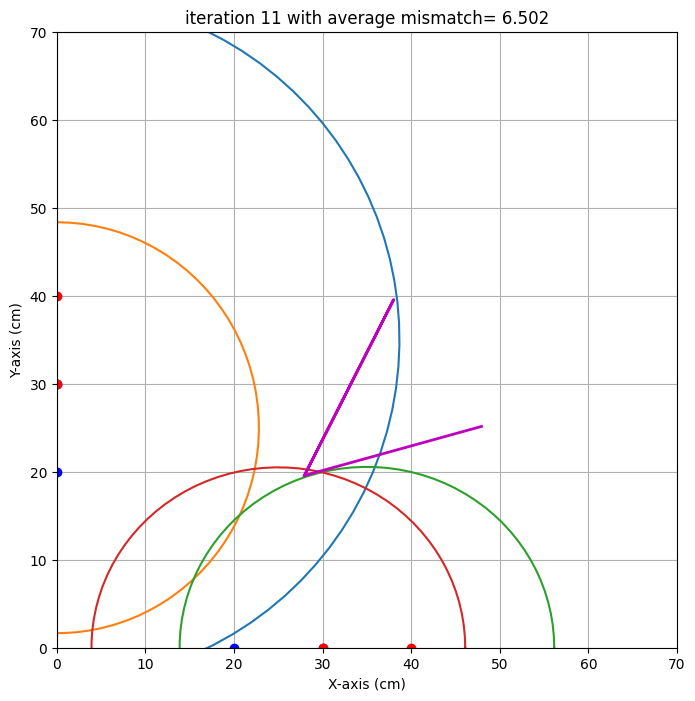

end iteration 11 with average mismatch= 6.502


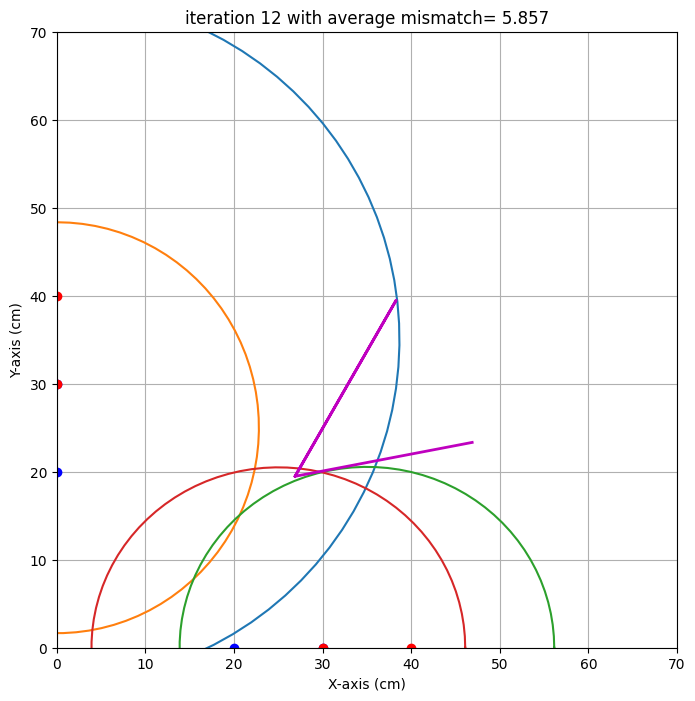

end iteration 12 with average mismatch= 5.857


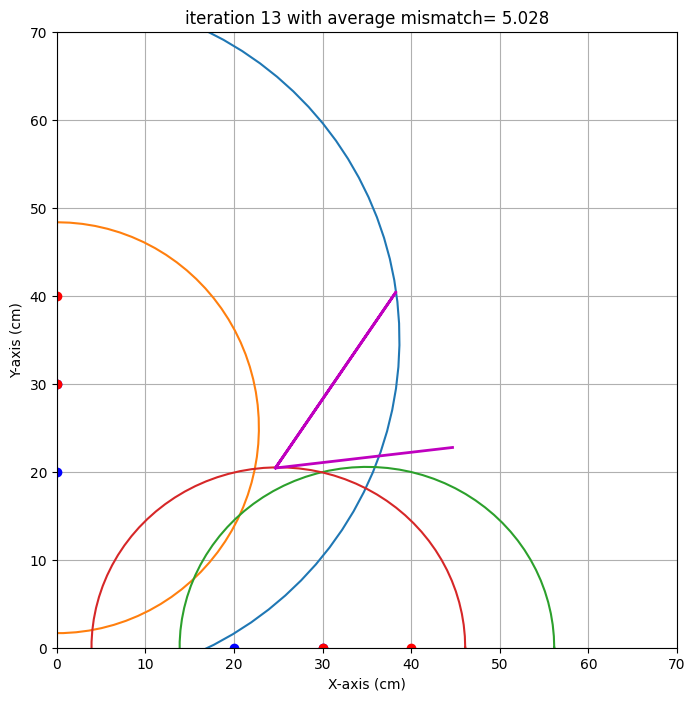

end iteration 13 with average mismatch= 5.028
end iteration 14 with average mismatch= 4.569


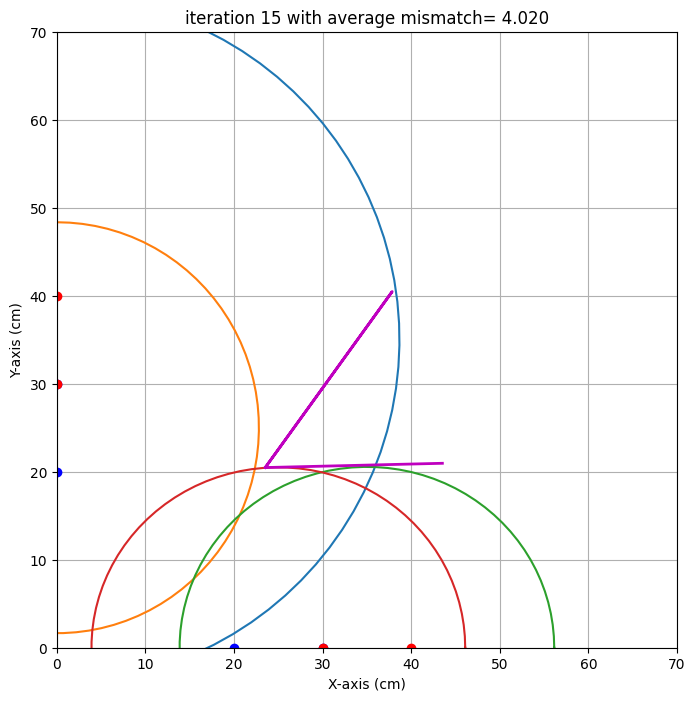

end iteration 15 with average mismatch= 4.020
end iteration 16 with average mismatch= 4.013
end iteration 17 with average mismatch= 3.830
end iteration 18 with average mismatch= 3.823
end iteration 19 with average mismatch= 3.817
end iteration 20 with average mismatch= 3.730
end iteration 21 with average mismatch= 3.730
end iteration 22 with average mismatch= 3.730
end iteration 23 with average mismatch= 3.730
end iteration 24 with average mismatch= 3.730
end iteration 25 with average mismatch= 3.730
end iteration 26 with average mismatch= 3.730
end iteration 27 with average mismatch= 3.730
end iteration 28 with average mismatch= 3.730
end iteration 29 with average mismatch= 3.730
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 3.730
###############################################################################
end of iteration  30
Best alpha=   0.50 with uncertainty=   2.55
Best beta 

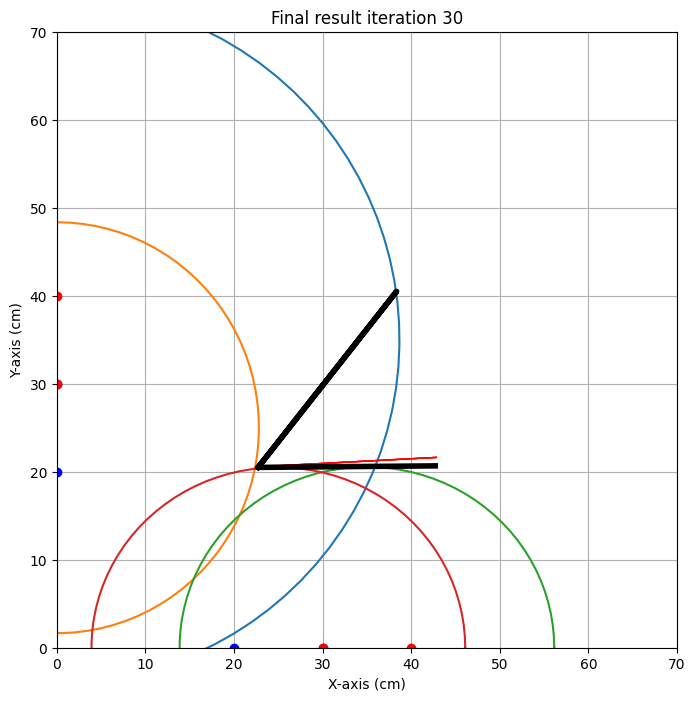

In [19]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,78.0],
    [0,30,0,20,46.7],
    #[0,10,0,20,],
    [40,0,30,0,42.3],
    [30,0,20,0,42.2],
    #[10,0,20,0,],
    #[10,0,0,10,]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 11.4 cm met een standaardafwijking van 3.7 cm 
y0: 8.7 cm met een standaardafwijking van 4.0 cm 
alpha: -31.7 graden met een standaardafwijking van 11.3 graad 
beta: -42.0 graden met een standaardafwijking van 12.7 graad 



## Opdracht 5: Iteratie 0

#### algoritme Bruno Schouten
Voeg een foto in van het algoritme van het eerste groepslid
<img src="bruno_schets.png" width="400">

#### algoritme Floor
Voeg een foto in van het algoritme van het tweede groepslid
<img src="floor_schets.png" width="400">

#### algoritme Job
Voeg een foto in van het algoritme van het derde groepslid
<img src="job_schets.png" width="400">

## Opdracht 6: Test iteratie 0.

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':40,  #zelf aanvullen,
           'y0':42,#zelf aanvullen,
           'alpha' : 5,#zelf aanvullen,
           'beta' : 5 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Bruno' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,30,0,60,86],
    [30,0,60,0,92],
    #[20,0,40,0, ], #error meting
    [0,50,0,70, 86.12],
    [40,0,70,0,87.77] 
    ]),
       'Floor' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [60,0,70,0,83.7],
    [55,0,65,0,83.9],
    #[20,0,30,0,], #error meting
    #[0,20,0,30, 85.],
    [0,60,0,70,91.0],
    [0,45,0,55,87.2],
    ]) 
    }
       




Opmerkingen Bruno algoritme: omdat de afstand tot de y-as kleiner is dan de afstand tot de x-as. Wordt er doorgemeten op de y-as
r_y < r_x (r_x_ellips reikt dichterbij de oorsprong, de r_y_ellips worden de brandpunten gezet hoger op de y-as)
hierdoor worden de gebieden afgezet langs de y-as naar boven
de error vertelt ons dat het object zich niet dicht bij de oorsprong bevindt 
we zoeken posities zo ver mogelijk op de x-as 

## Opdracht 7: Evaluatie.

Bruno
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  30   0  60  86.00
1  30   0  60   0  92.00
2   0  50   0  70  86.12
3  40   0  70   0  87.77


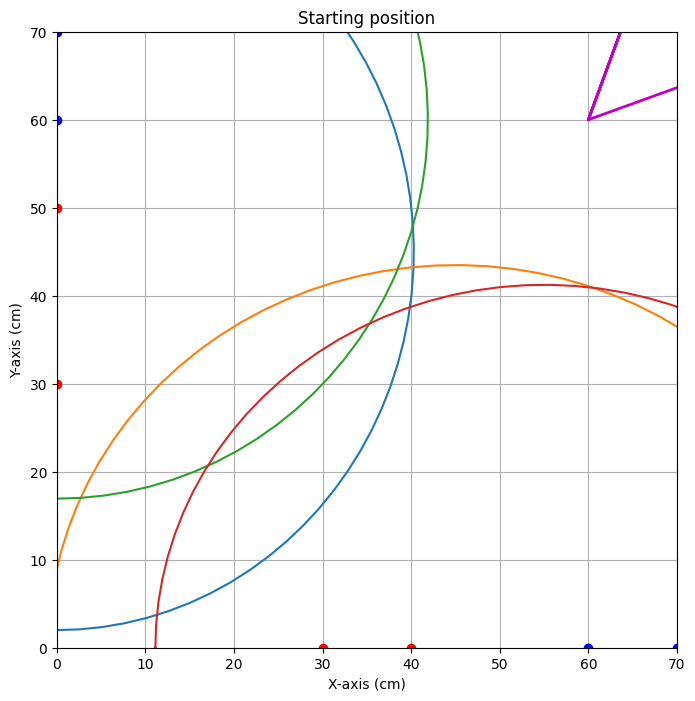


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.766


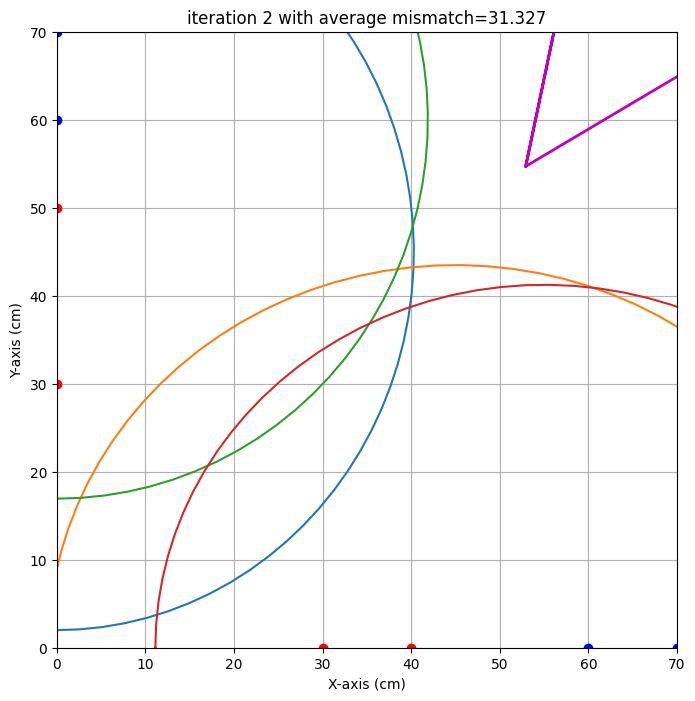

end iteration 2 with average mismatch=31.327


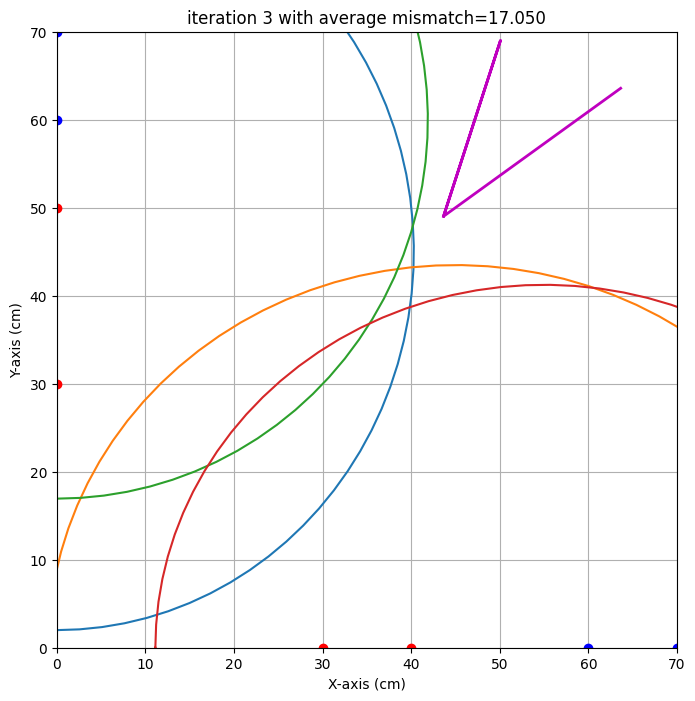

end iteration 3 with average mismatch=17.050


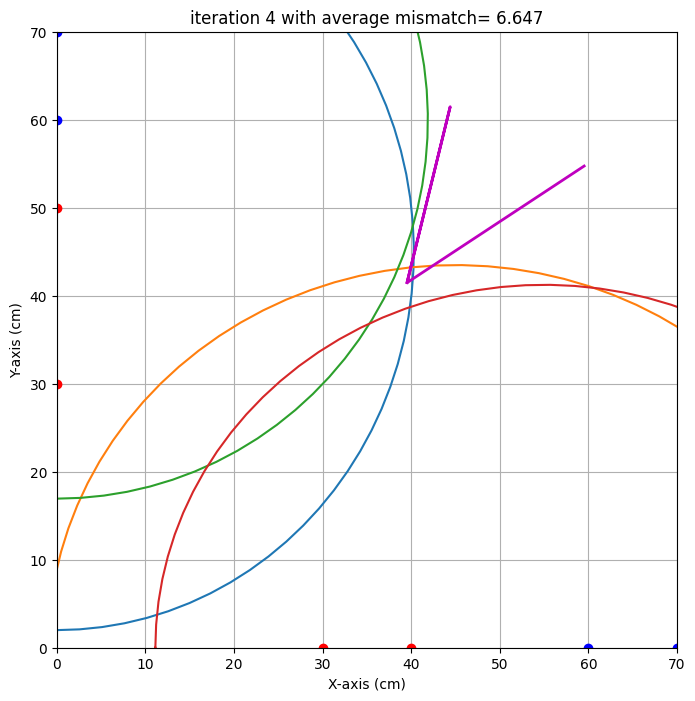

end iteration 4 with average mismatch= 6.647


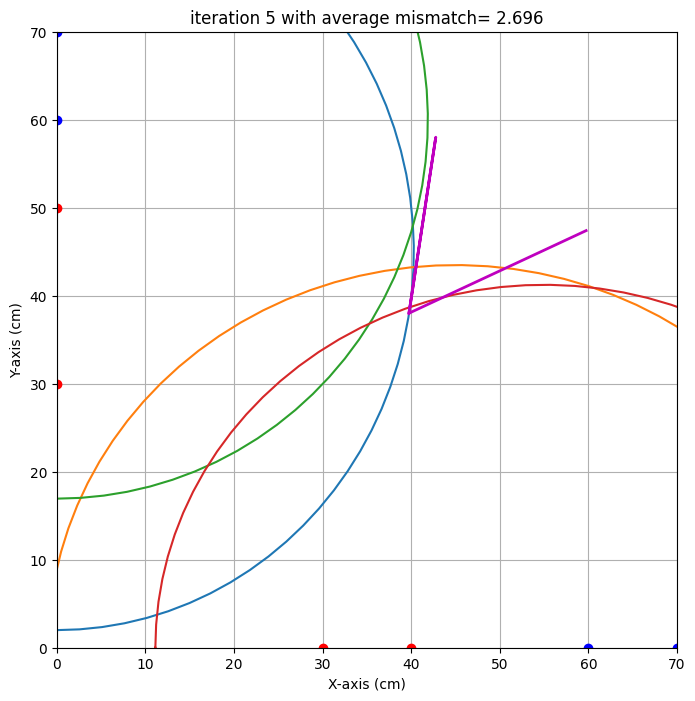

end iteration 5 with average mismatch= 2.696


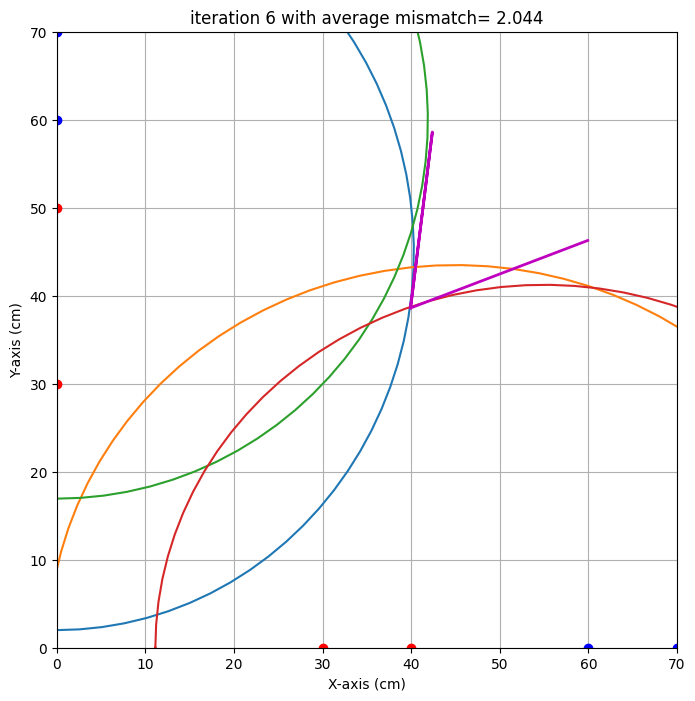

end iteration 6 with average mismatch= 2.044
end iteration 7 with average mismatch= 2.042
end iteration 8 with average mismatch= 2.024


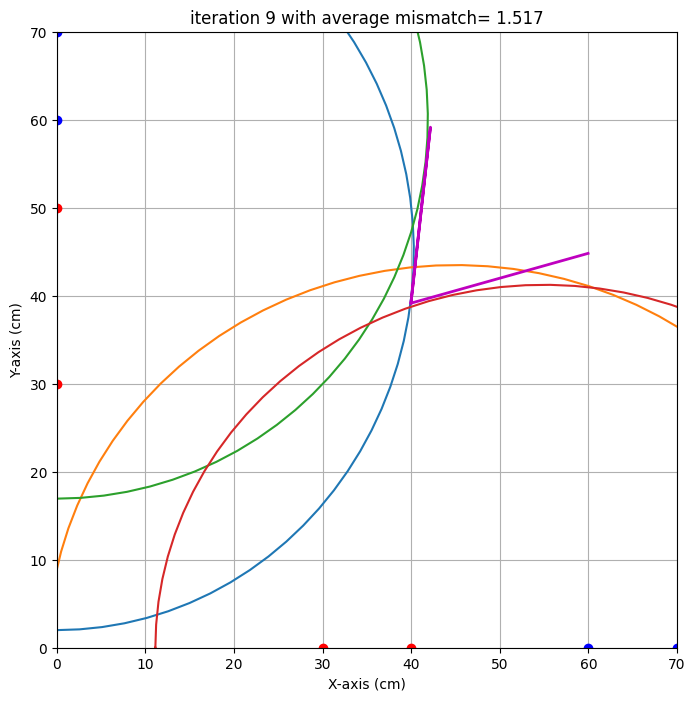

end iteration 9 with average mismatch= 1.517
end iteration 10 with average mismatch= 1.516
end iteration 11 with average mismatch= 1.504
end iteration 12 with average mismatch= 1.420
end iteration 13 with average mismatch= 1.407
end iteration 14 with average mismatch= 1.400
end iteration 15 with average mismatch= 1.400
end iteration 16 with average mismatch= 1.400
end iteration 17 with average mismatch= 1.400
end iteration 18 with average mismatch= 1.400
end iteration 19 with average mismatch= 1.400
end iteration 20 with average mismatch= 1.400
end iteration 21 with average mismatch= 1.400
end iteration 22 with average mismatch= 1.400
end iteration 23 with average mismatch= 1.393
end iteration 24 with average mismatch= 1.343
end iteration 25 with average mismatch= 1.343
end iteration 26 with average mismatch= 1.343
end iteration 27 with average mismatch= 1.343
end iteration 28 with average mismatch= 1.343
end iteration 29 with average mismatch= 1.343
Last iteration, also determine unce

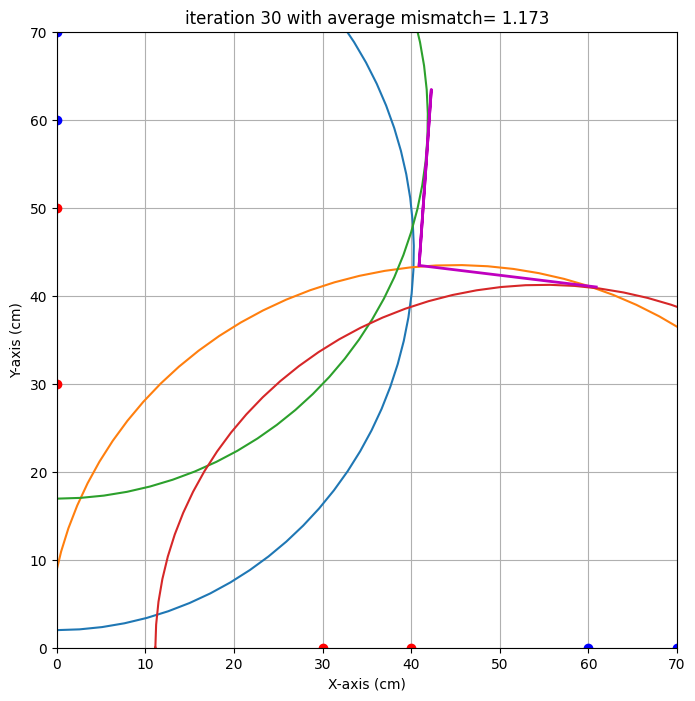

end iteration 30 with average mismatch= 1.173
###############################################################################
end of iteration  30
Best alpha=  -6.98 with uncertainty=  14.07
Best beta =   3.94 with uncertainty=   7.89
Best x0   =  40.89 with uncertainty=   1.23
Best y0   =  43.44 with uncertainty=   3.69
###############################################################################


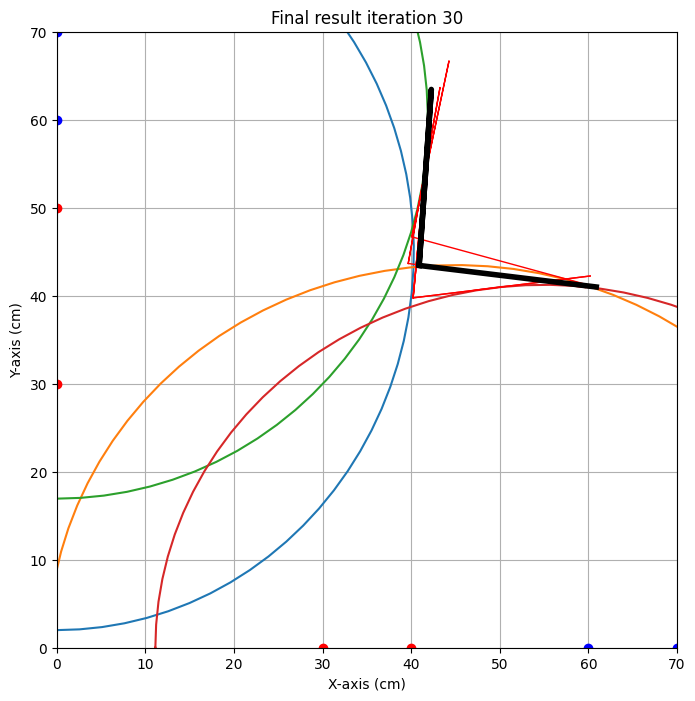

{'alpha': np.float64(-6.978564424476566), 'alpha_eps': np.float64(14.069791904762857), 'beta': np.float64(3.939294544491632), 'beta_eps': np.float64(7.890001229125549), 'x0': np.float64(40.89465971344114), 'x0_eps': np.float64(1.23262807832171), 'y0': np.float64(43.441068409856186), 'y0_eps': np.float64(3.685894885060833)}
Floor
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  60   0  70   0  83.7
1  55   0  65   0  83.9
2   0  60   0  70  91.0
3   0  45   0  55  87.2


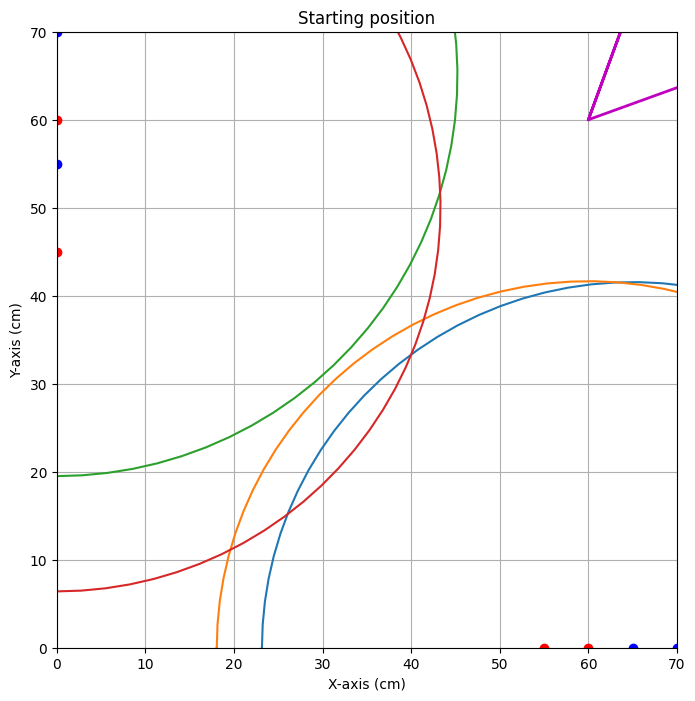


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=40.027


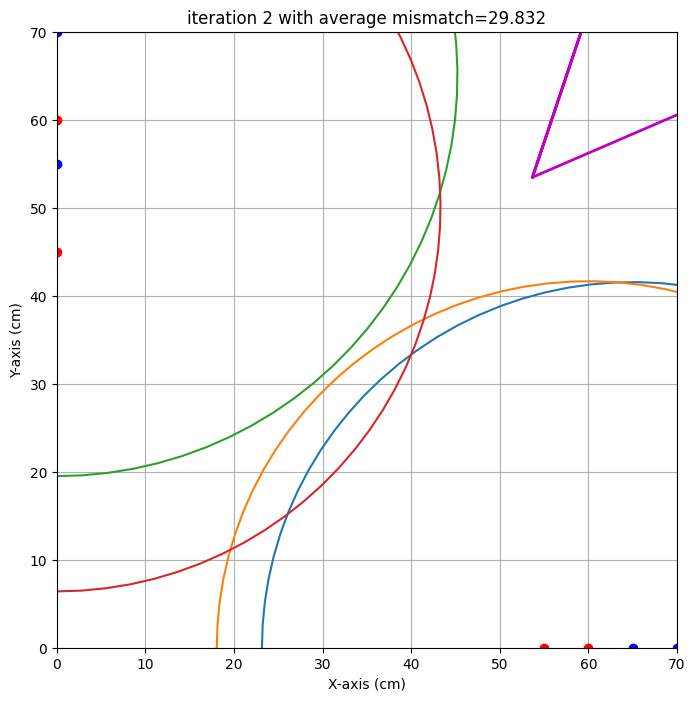

end iteration 2 with average mismatch=29.832


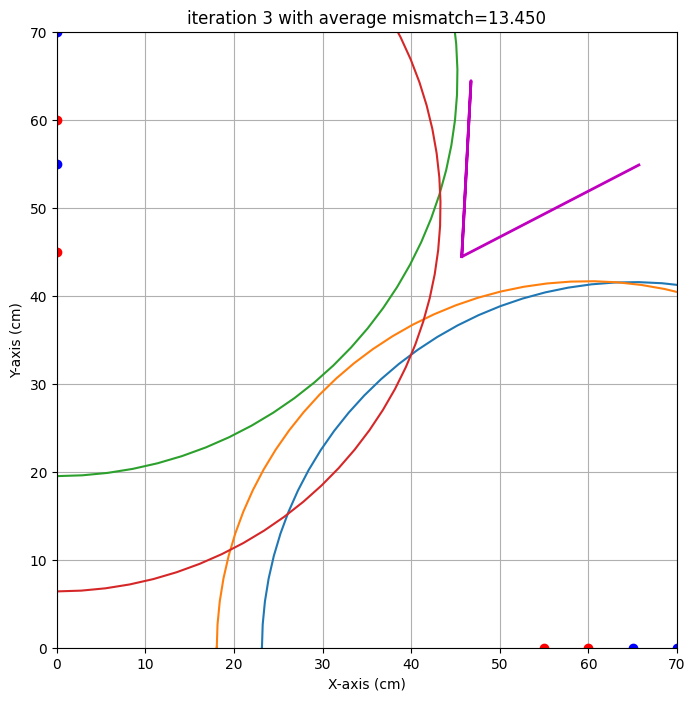

end iteration 3 with average mismatch=13.450


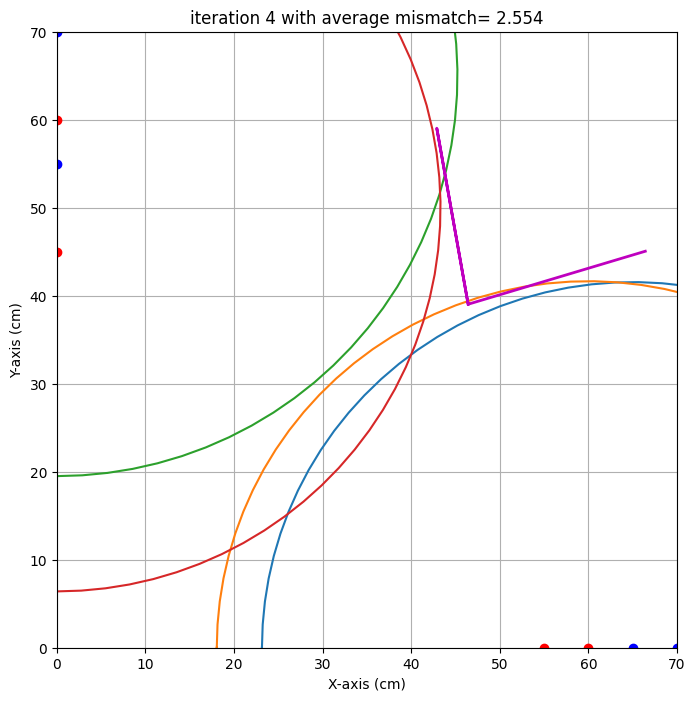

end iteration 4 with average mismatch= 2.554


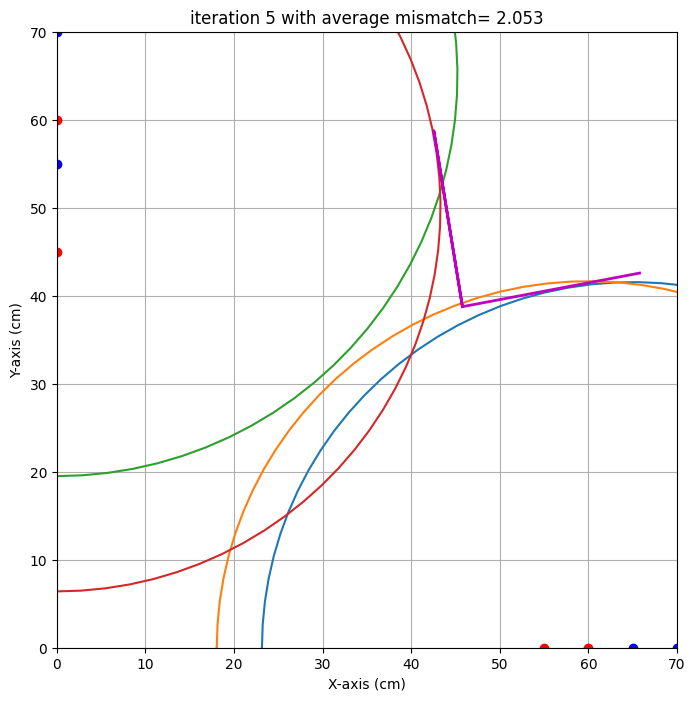

end iteration 5 with average mismatch= 2.053


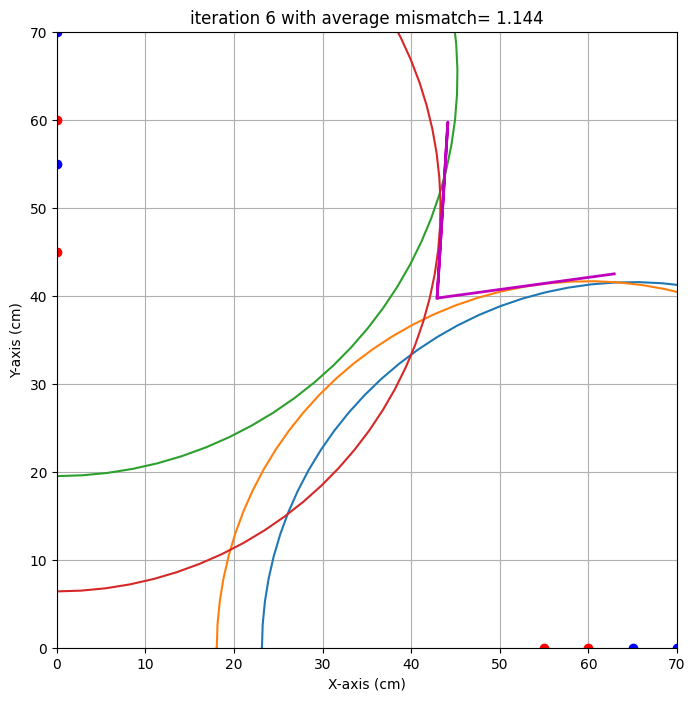

end iteration 6 with average mismatch= 1.144


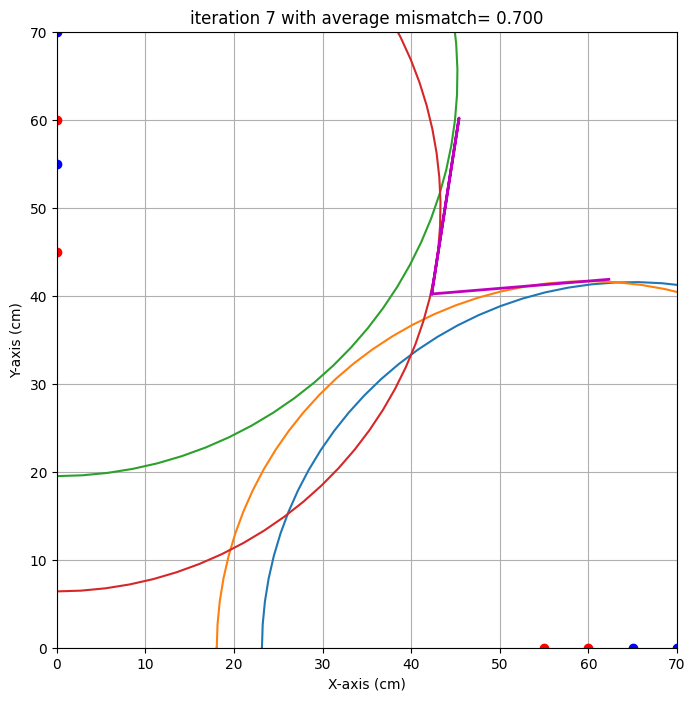

end iteration 7 with average mismatch= 0.700


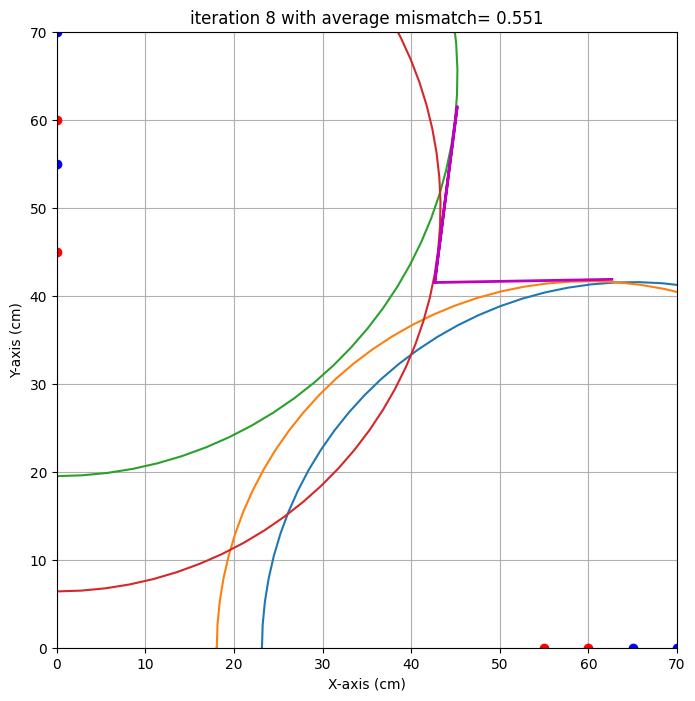

end iteration 8 with average mismatch= 0.551


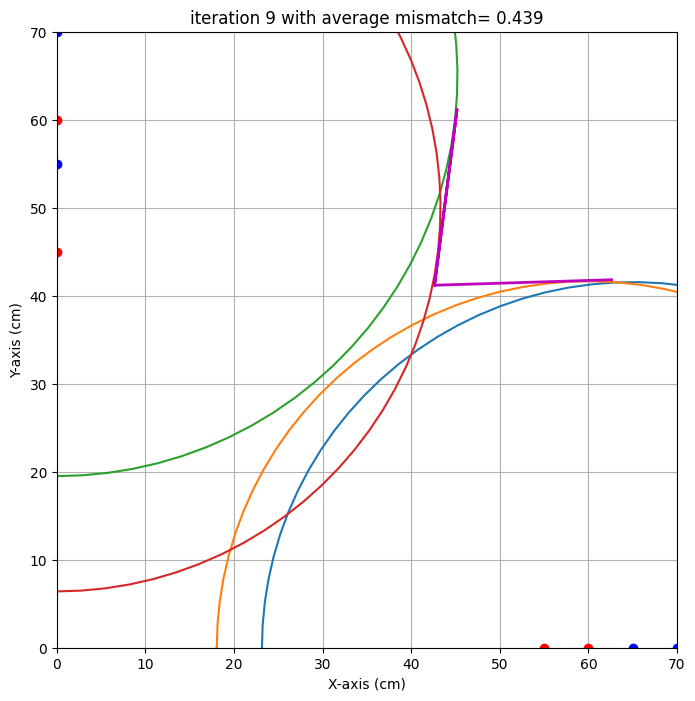

end iteration 9 with average mismatch= 0.439


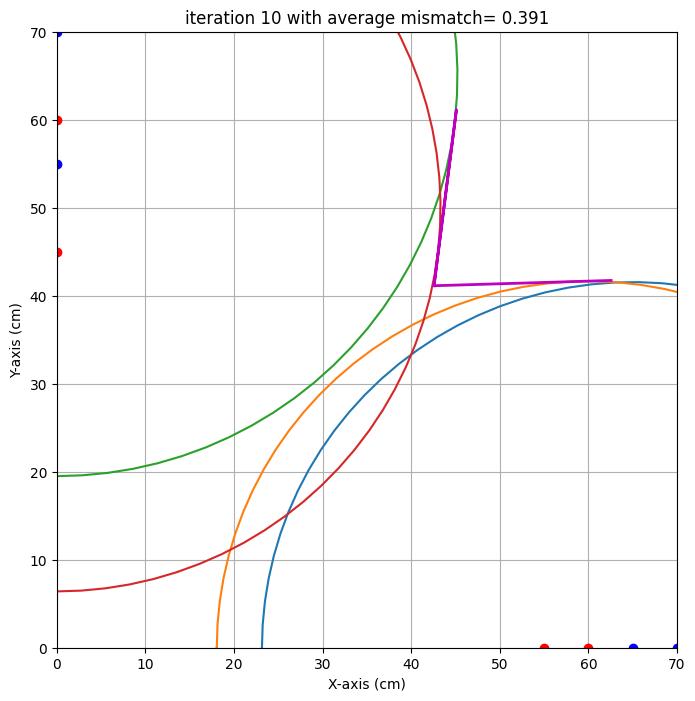

end iteration 10 with average mismatch= 0.391
end iteration 11 with average mismatch= 0.391
end iteration 12 with average mismatch= 0.391
end iteration 13 with average mismatch= 0.391
end iteration 14 with average mismatch= 0.391
end iteration 15 with average mismatch= 0.391
end iteration 16 with average mismatch= 0.391
end iteration 17 with average mismatch= 0.391
end iteration 18 with average mismatch= 0.391
end iteration 19 with average mismatch= 0.391
end iteration 20 with average mismatch= 0.391
end iteration 21 with average mismatch= 0.391
end iteration 22 with average mismatch= 0.391
end iteration 23 with average mismatch= 0.391
end iteration 24 with average mismatch= 0.391
end iteration 25 with average mismatch= 0.391
end iteration 26 with average mismatch= 0.391
end iteration 27 with average mismatch= 0.391
end iteration 28 with average mismatch= 0.391
end iteration 29 with average mismatch= 0.391
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

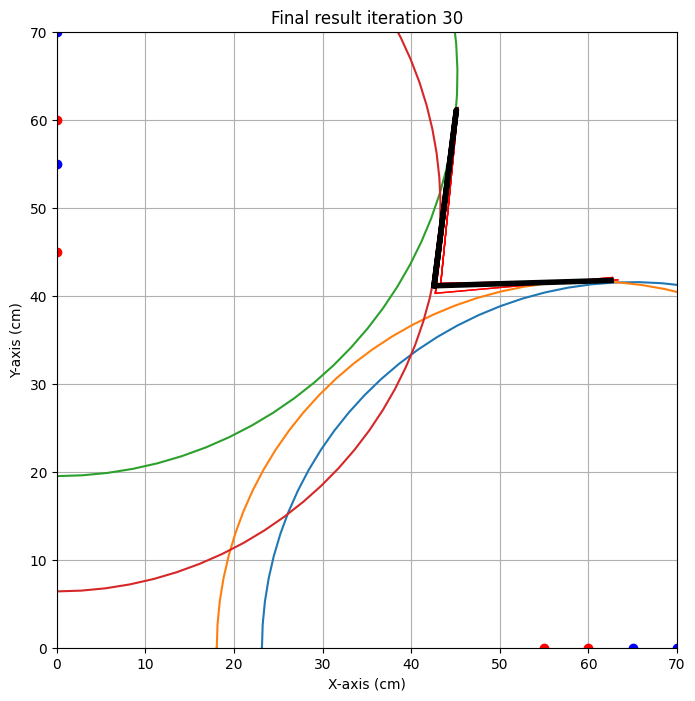

{'alpha': np.float64(1.7214135499100243), 'alpha_eps': np.float64(3.4097170402361003), 'beta': np.float64(7.213524303983463), 'beta_eps': np.float64(1.606859400591051), 'x0': np.float64(42.57401045545165), 'x0_eps': np.float64(0.7652136072740348), 'y0': np.float64(41.1341823141873), 'y0_eps': np.float64(0.8567393164379951)}


In [38]:
# Hier runnen we het imaging algoritme:
resultaat = dict()
studentNames = np.array(['Bruno','Floor'])

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [34]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Bruno 
x0 target is : 40.0. Gevonden waarde: 40.0 cm met een standaardafwijking van 1.1 cm 
y0 target is : 42.0. Gevonden waarde: 39.5 cm met een standaardafwijking van 4.3 cm 
alpha target is : 5.0. Gevonden waarde: 9.4 graden met een standaardafwijking van 14.7 graad 
beta target is : 5.0. Gevonden waarde: 5.8 graden met een standaardafwijking van 4.9 graad 

Floor 
x0 target is : 40.0. Gevonden waarde: 40.1 cm met een standaardafwijking van 2.2 cm 
y0 target is : 42.0. Gevonden waarde: 40.6 cm met een standaardafwijking van 4.5 cm 
alpha target is : 5.0. Gevonden waarde: 3.2 graden met een standaardafwijking van 13.3 graad 
beta target is : 5.0. Gevonden waarde: 5.9 graden met een standaardafwijking van 7.1 graad 



## Opdracht 8: Iteratie1+.1500
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](iteratie1.png)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  47.0
1  45   0  55   0  44.7
2  40   0  50   0  44.4
3  38   0  43   0  42.7
4   0  22   0  32  66.8
5   0  27   0  37  66.1
6   0  32   0  42  65.4


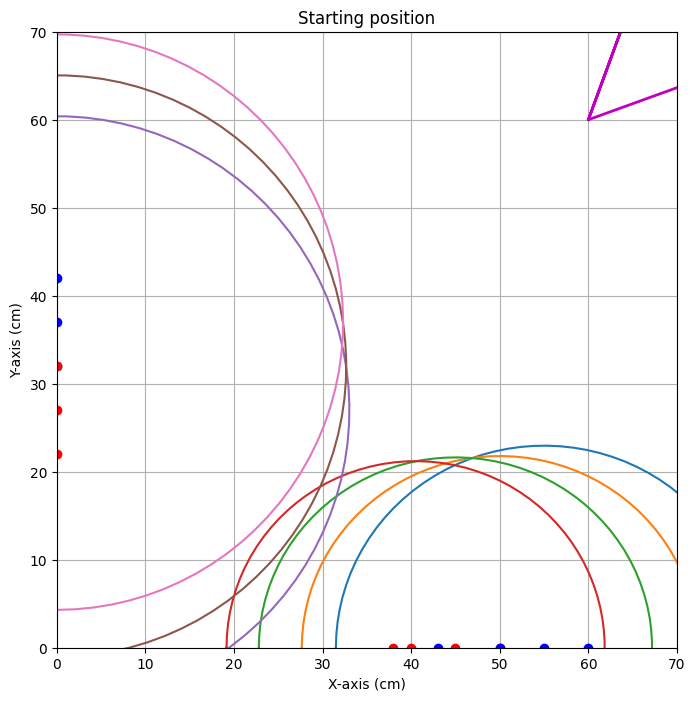


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=81.023


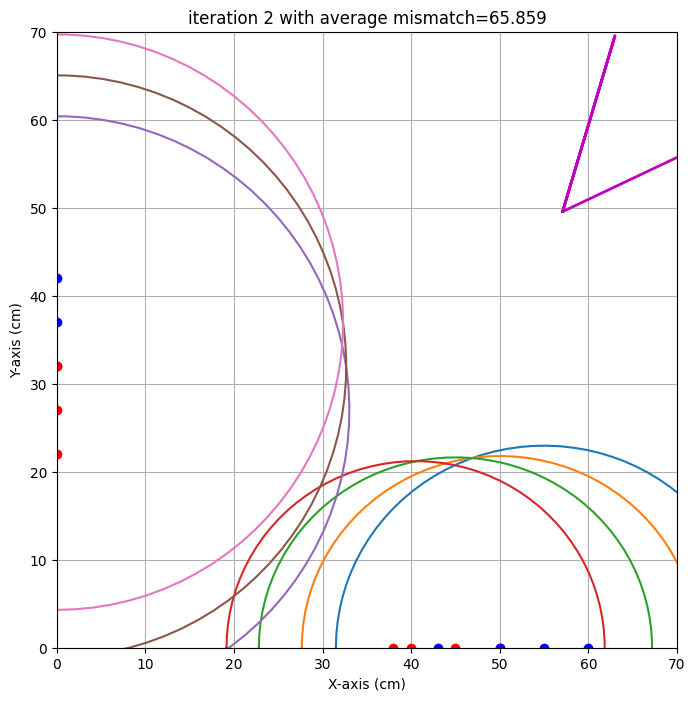

end iteration 2 with average mismatch=65.859


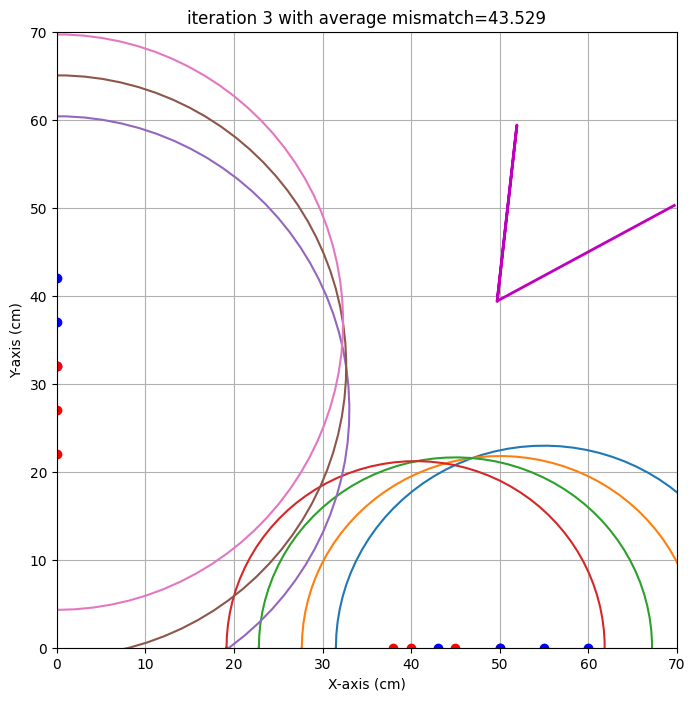

end iteration 3 with average mismatch=43.529


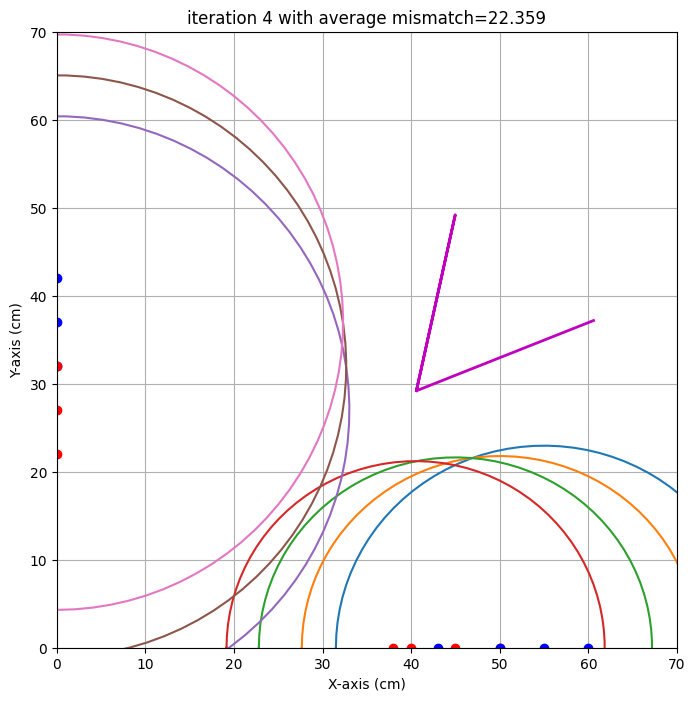

end iteration 4 with average mismatch=22.359


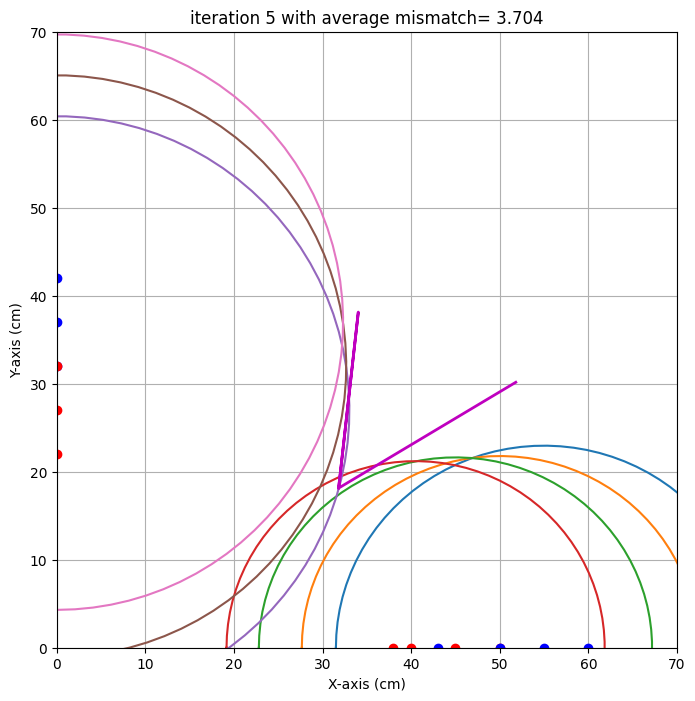

end iteration 5 with average mismatch= 3.704


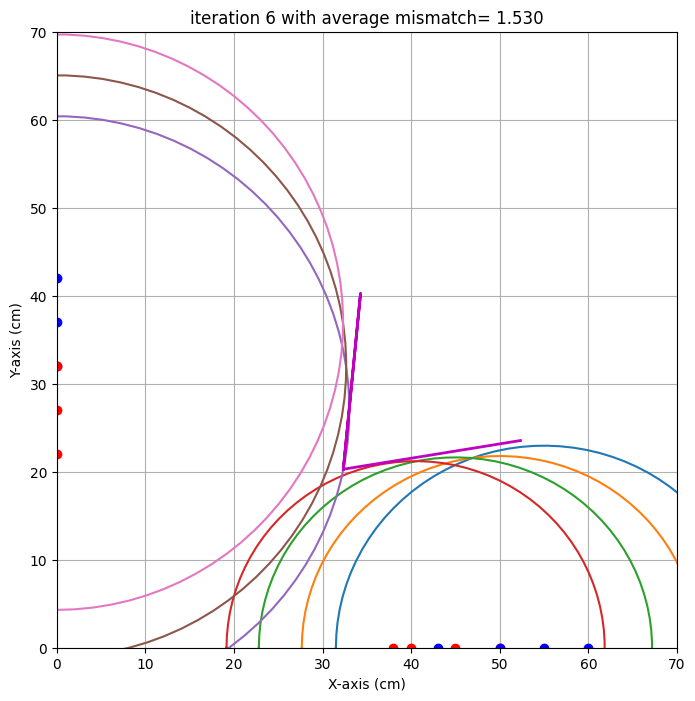

end iteration 6 with average mismatch= 1.530


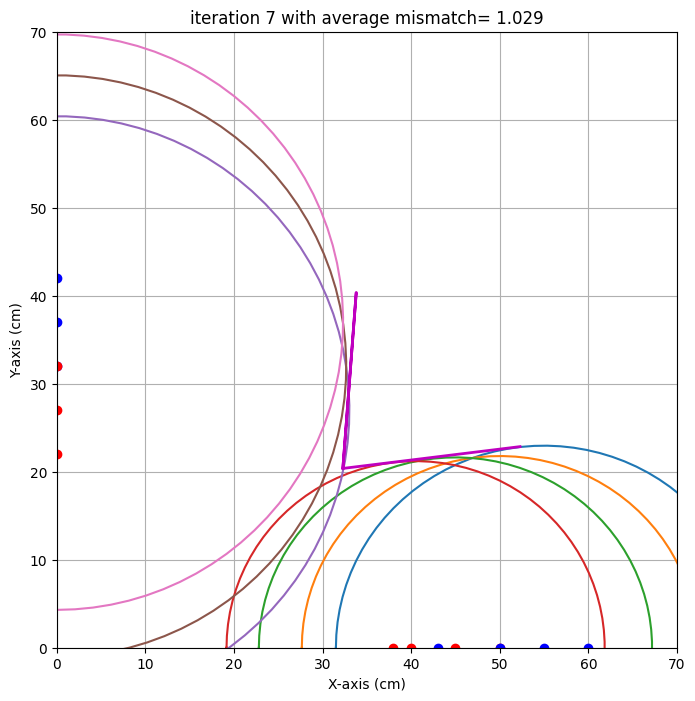

end iteration 7 with average mismatch= 1.029
end iteration 8 with average mismatch= 0.996
end iteration 9 with average mismatch= 0.995
end iteration 10 with average mismatch= 0.955
end iteration 11 with average mismatch= 0.903


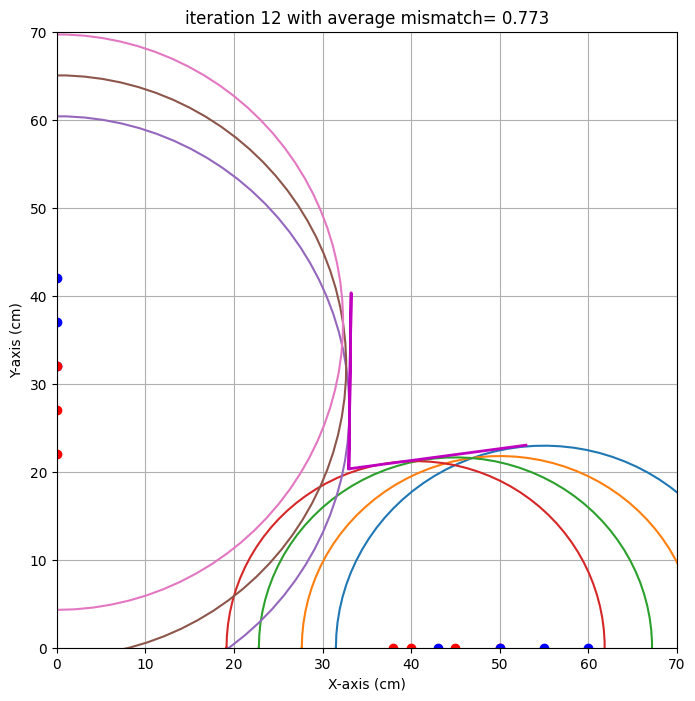

end iteration 12 with average mismatch= 0.773
end iteration 13 with average mismatch= 0.752


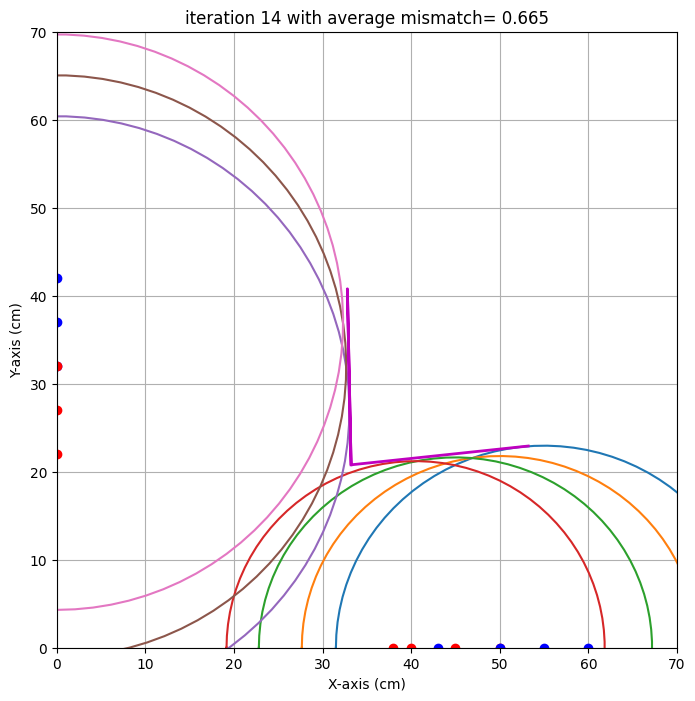

end iteration 14 with average mismatch= 0.665
end iteration 15 with average mismatch= 0.631
end iteration 16 with average mismatch= 0.605


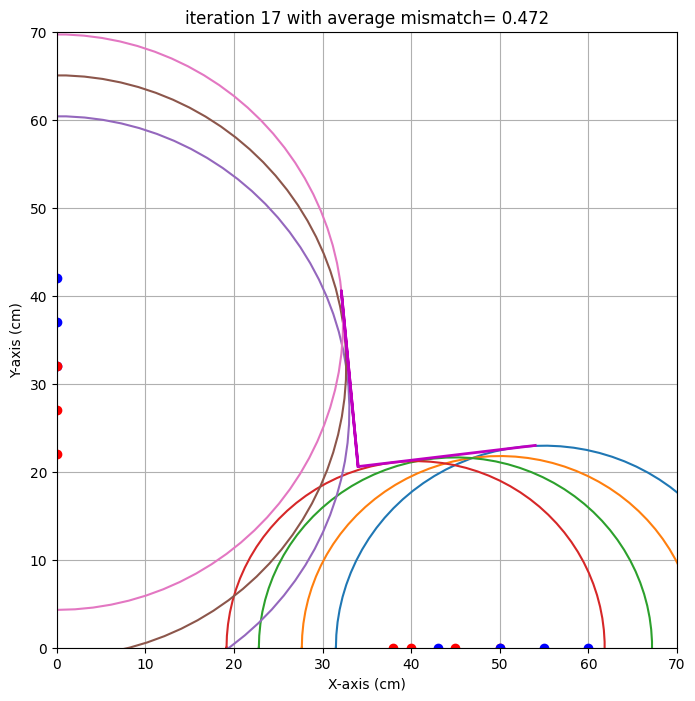

end iteration 17 with average mismatch= 0.472
end iteration 18 with average mismatch= 0.471


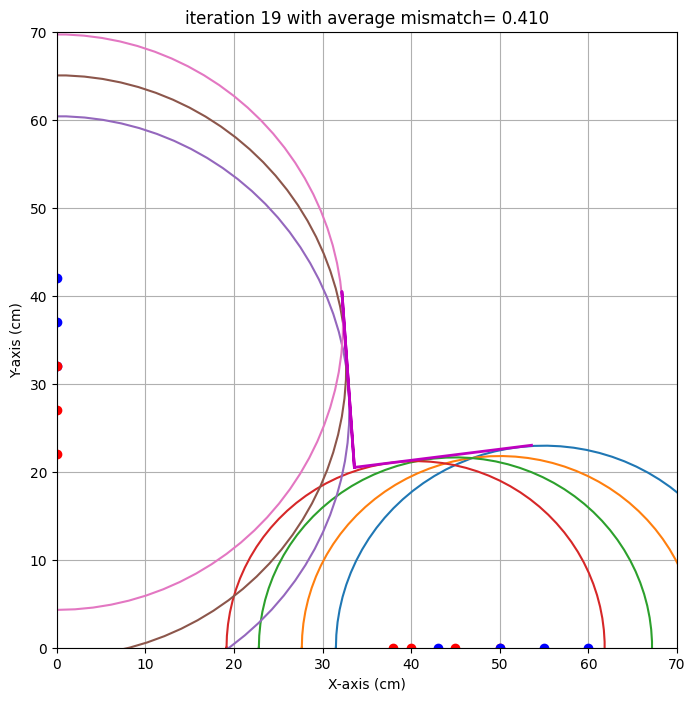

end iteration 19 with average mismatch= 0.410
end iteration 20 with average mismatch= 0.381
end iteration 21 with average mismatch= 0.378
end iteration 22 with average mismatch= 0.377
end iteration 23 with average mismatch= 0.377
end iteration 24 with average mismatch= 0.371
end iteration 25 with average mismatch= 0.371
end iteration 26 with average mismatch= 0.371
end iteration 27 with average mismatch= 0.370
end iteration 28 with average mismatch= 0.370
end iteration 29 with average mismatch= 0.370
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.370
###############################################################################
end of iteration  30
Best alpha=   6.91 with uncertainty=   3.16
Best beta =  -4.28 with uncertainty=   1.21
Best x0   =  33.63 with uncertainty=   0.14
Best y0   =  20.53 with uncertainty=   0.42
#####################################

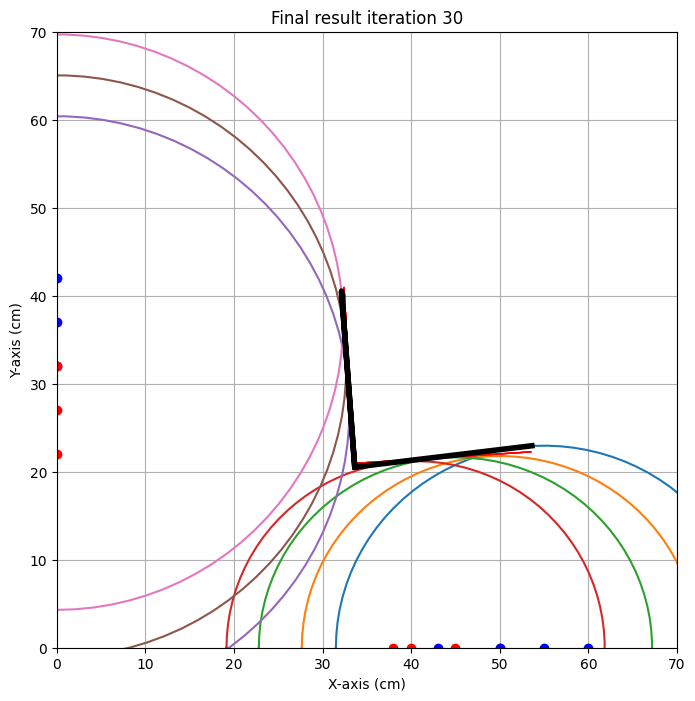

{'alpha': np.float64(6.910017252683912), 'alpha_eps': np.float64(3.1580123317238606), 'beta': np.float64(-4.280898402858259), 'beta_eps': np.float64(1.2141442157648), 'x0': np.float64(33.625804781408505), 'x0_eps': np.float64(0.1362912310776423), 'y0': np.float64(20.52744923478899), 'y0_eps': np.float64(0.41524632866520506)}
locatie 1 
x0 target is : 0.0. Gevonden waarde: 33.6 cm met een standaardafwijking van 0.1 cm 
y0 target is : 0.0. Gevonden waarde: 20.5 cm met een standaardafwijking van 0.4 cm 
alpha target is : 0.0. Gevonden waarde: 6.9 graden met een standaardafwijking van 3.2 graad 
beta target is : 0.0. Gevonden waarde: -4.3 graden met een standaardafwijking van 1.2 graad 



In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':34.2,#zelf aanvullen,
                    'y0':21.1,#zelf aanvullen,
                    'alpha' :3.1, #zelf aanvullen,
                    'beta' :-4.8 #zelf aanvullen},         
}}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [50, 0, 60, 0,47.0 ],
                    [45,0,55,0,44.7],
                    [40,0,50,0,44.4],
                    [38,0,43,0,42.70],
                    [0,22,0,32,66.8],
                    [0,27,0,37,66.1],
                    [0,32,0,42,65.4]
    ])
       
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
     xs  ys  xr  yr      R
0  50.0   0  55   0  42.34
1  45.0   0  50   0  43.48
2  40.5   0  45   0  43.69
3   0.0  21   0  31  65.02
4   0.0  26   0  32  63.89
5   0.0  31   0  37  62.96


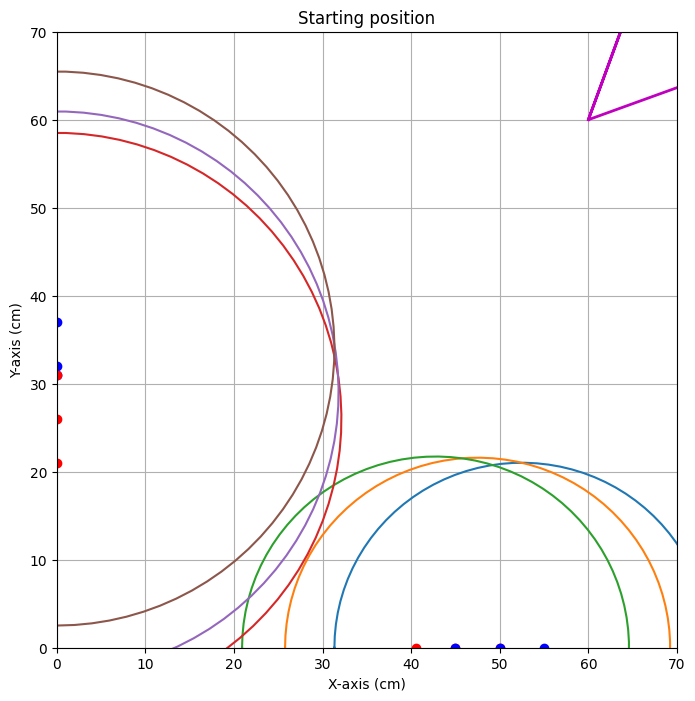


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=82.617


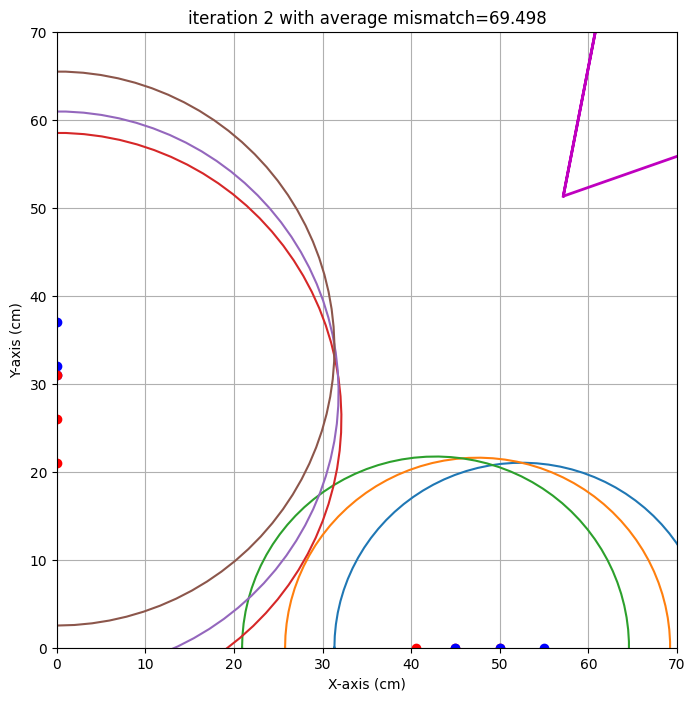

end iteration 2 with average mismatch=69.498


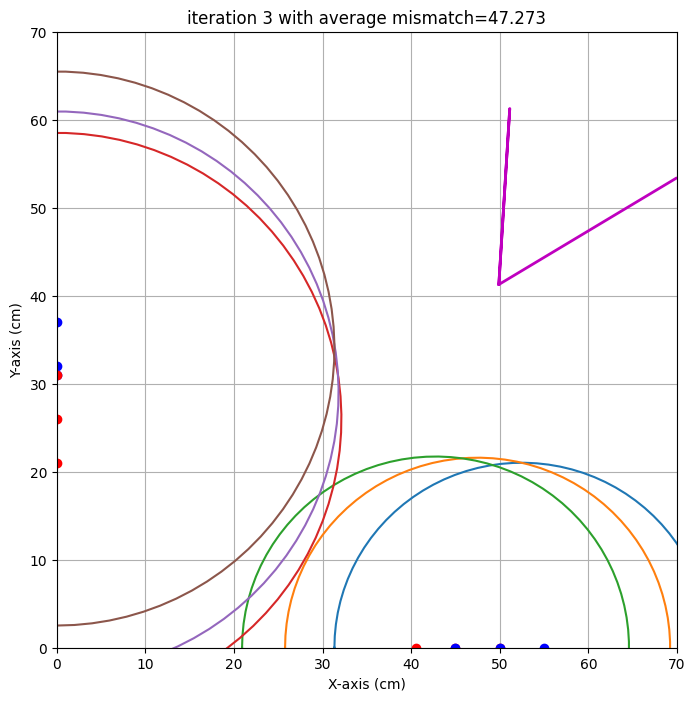

end iteration 3 with average mismatch=47.273


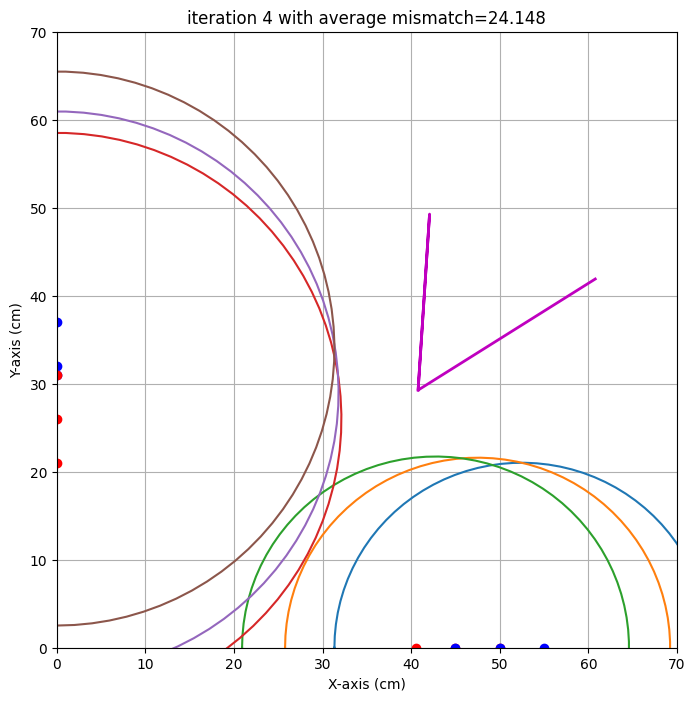

end iteration 4 with average mismatch=24.148


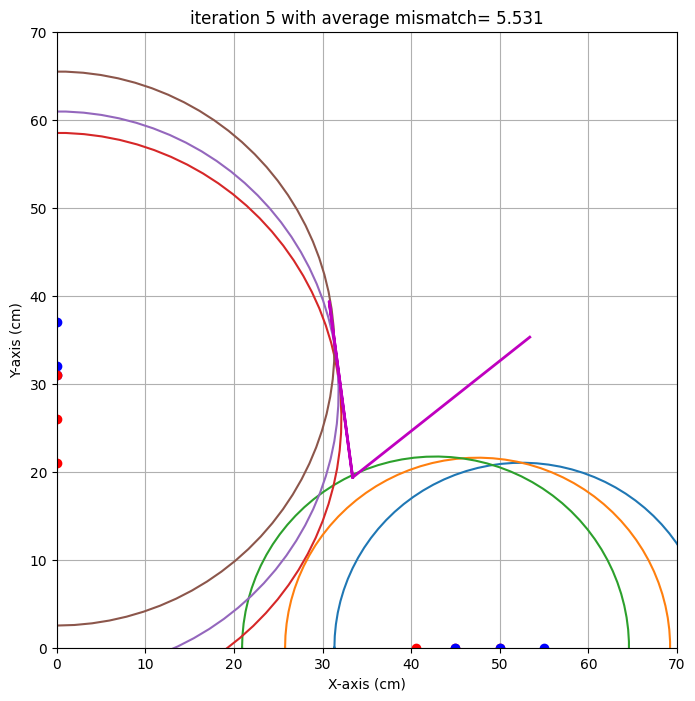

end iteration 5 with average mismatch= 5.531


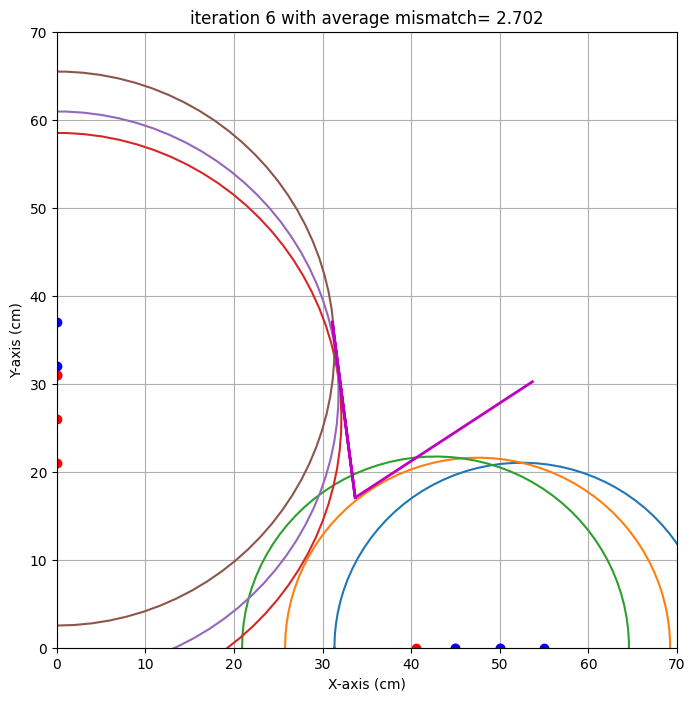

end iteration 6 with average mismatch= 2.702
end iteration 7 with average mismatch= 2.632
end iteration 8 with average mismatch= 2.463
end iteration 9 with average mismatch= 2.457
end iteration 10 with average mismatch= 2.456
end iteration 11 with average mismatch= 2.413


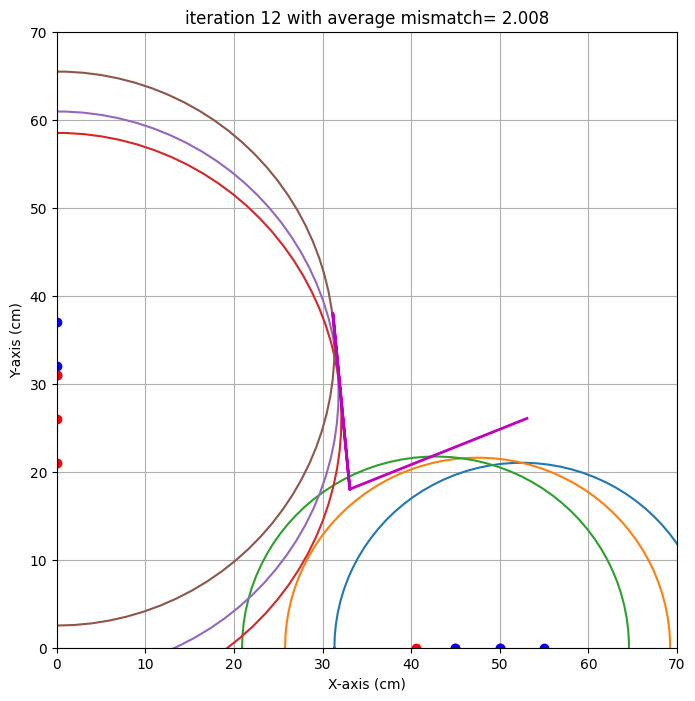

end iteration 12 with average mismatch= 2.008


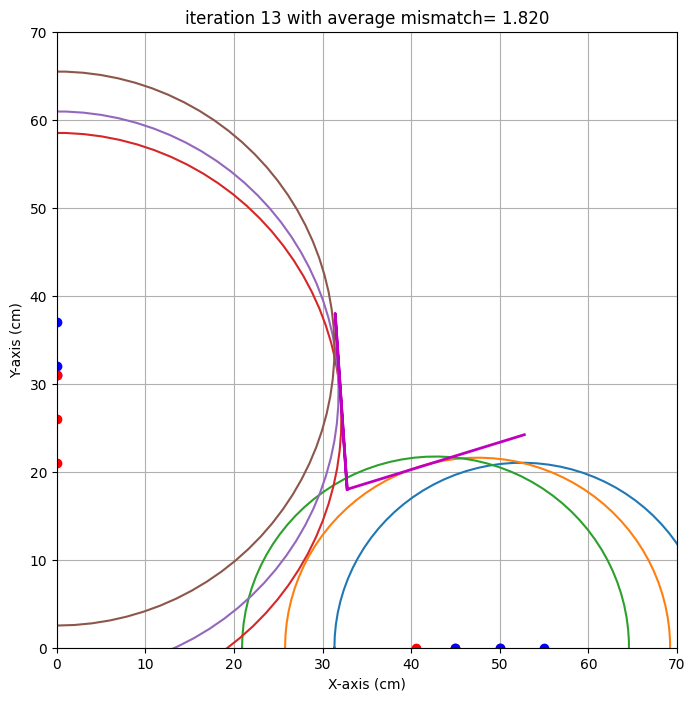

end iteration 13 with average mismatch= 1.820
end iteration 14 with average mismatch= 1.703
end iteration 15 with average mismatch= 1.700
end iteration 16 with average mismatch= 1.698
end iteration 17 with average mismatch= 1.558


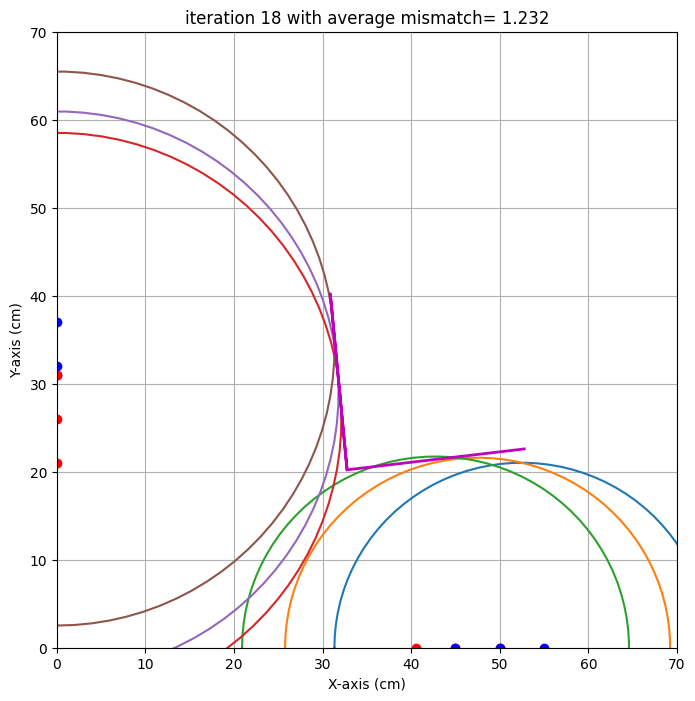

end iteration 18 with average mismatch= 1.232


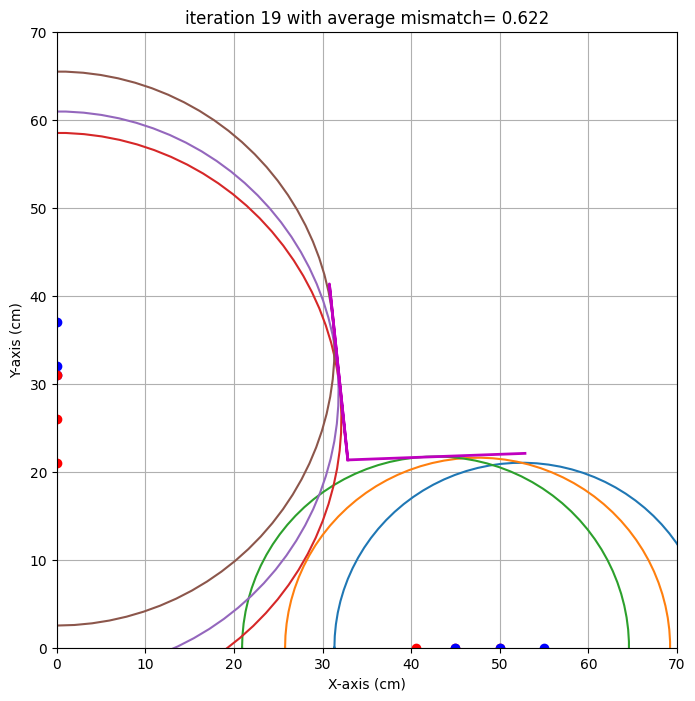

end iteration 19 with average mismatch= 0.622
end iteration 20 with average mismatch= 0.604
end iteration 21 with average mismatch= 0.602
end iteration 22 with average mismatch= 0.602
end iteration 23 with average mismatch= 0.587
end iteration 24 with average mismatch= 0.582


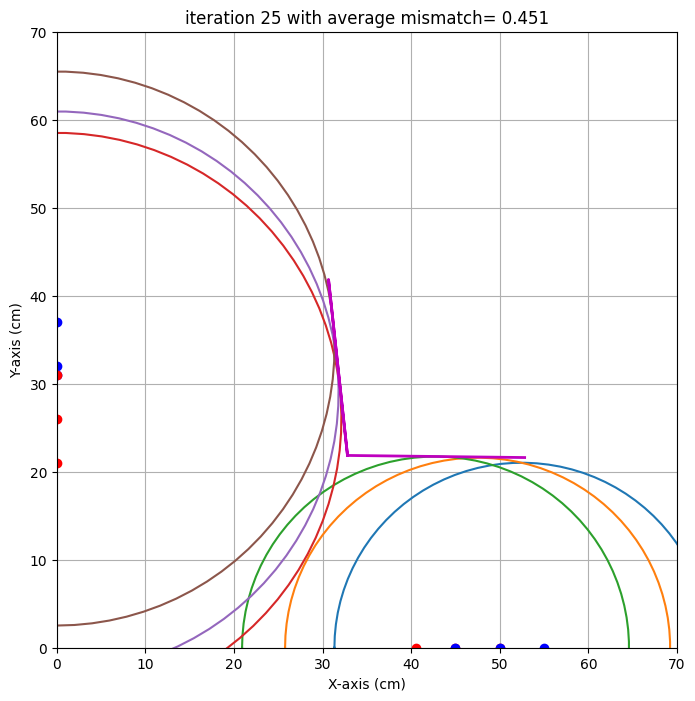

end iteration 25 with average mismatch= 0.451
end iteration 26 with average mismatch= 0.446
end iteration 27 with average mismatch= 0.444
end iteration 28 with average mismatch= 0.444
end iteration 29 with average mismatch= 0.444
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.444
###############################################################################
end of iteration  30
Best alpha=  -0.69 with uncertainty=   4.32
Best beta =  -6.13 with uncertainty=   3.73
Best x0   =  32.80 with uncertainty=   0.60
Best y0   =  21.84 with uncertainty=   1.08
###############################################################################


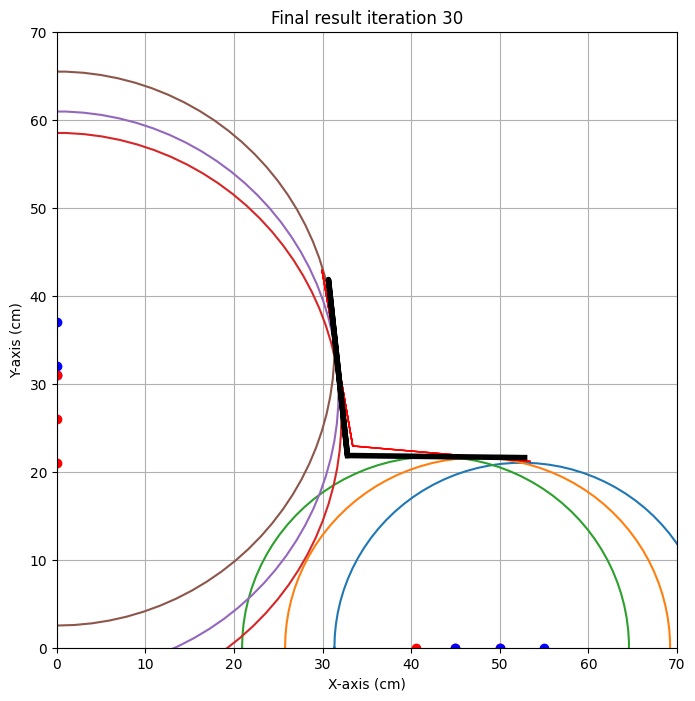

{'alpha': np.float64(-0.6869712168148535), 'alpha_eps': np.float64(4.317821629016793), 'beta': np.float64(-6.125081191063206), 'beta_eps': np.float64(3.7311884247336913), 'x0': np.float64(32.80429142322844), 'x0_eps': np.float64(0.5978898707165854), 'y0': np.float64(21.84206538094142), 'y0_eps': np.float64(1.0825411118715351)}
test locatie 
x0 target is : 32.2. Gevonden waarde: 32.8 cm met een standaardafwijking van 0.6 cm 
y0 target is : 22.0. Gevonden waarde: 21.8 cm met een standaardafwijking van 1.1 cm 
alpha target is : -4.4. Gevonden waarde: -0.7 graden met een standaardafwijking van 4.3 graad 
beta target is : -4.6. Gevonden waarde: -6.1 graden met een standaardafwijking van 3.7 graad 



In [49]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 32.2,  # zelf aanvullen,
                    'y0': 22.0, # zelf aanvullen,
                    'alpha' : -4.42,#zelf aanvullen,
                    'beta' : -4.57 #zelf aanvullen},
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    #[60, 0, 70, 0,0 ],  #error
                    [50, 0, 55, 0,42.34 ],
                    [45,0,50,0,43.48],
                    [40.5,0,45,0,43.69],
                    [0,21,0,31,65.02],
                    [0,26,0,32,63.89],
                    [0,31,0,37,62.96]


                    # zelf aanvullen
                    ])
                }






# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](1.png "Title")
Alle mogelijke opties proberen, ver weg in de as en dichtbij. Alle metingen gingen tegelijk, dit maakte het algoritme erg ingewikkeld en niet bruikbaar. Hierdoor gingen we door naar de volgende:

Figuur: ![Alt](2.png "Title")
Hier probeerden we de grootste delen van de as te vinden, en te kijken bij welke as het object dichterbij was. Het werkte wel beter, maar het idee om alleen eerst op 1 as te werken werd geboren. Want op 2 assen telkens zoeken bleek ingewikkeld

Figuur: ![Alt](3.png "Title")
Hierbij begonnen we op 1 as elke positie af te gaan, waardoor we na maximaal 5 pogingen een hit hadden. Na deze hit zou het vlak bepalen op de andere as maar 2 hits kosten. 

Conclusie:
Door de fouten en goede eigenschappen van de vorige algoritme is de 3e/laatste algorimte in staat de positie en hoek van een bepaald object te benaderen.